# Part 4 : K-Means Clustering

**Durée estimée : 2h**

## 🎯 Objectifs d'apprentissage

À la fin de cette partie, vous serez capable de :
1. **Expliquer** la différence entre apprentissage supervisé et non-supervisé
2. **Décrire** l'algorithme K-Means étape par étape
3. **Appliquer** la méthode du coude pour choisir le nombre de clusters
4. **Interpréter** les clusters dans un contexte business

---

## 🌍 Problème Réel : Comment Spotify crée-t-il vos playlists personnalisées ?

Chaque vendredi, Spotify vous propose une playlist "Discover Weekly" avec 30 chansons que vous n'avez jamais écoutées... mais que vous allez probablement adorer.

**Question :** Comment Spotify peut-il deviner vos goûts musicaux sans que vous ayez explicitement dit "j'aime le rock alternatif des années 90" ?

*(Prenez 30 secondes pour réfléchir...)*

<details>
<summary>🤔 Votre intuition ?</summary>

### 🔑 Réponse

Spotify ne vous demande pas vos genres préférés. Il **observe** votre comportement :
- Quelles chansons écoutez-vous en boucle ?
- Lesquelles sautez-vous après 10 secondes ?
- À quelle heure écoutez-vous de la musique calme vs énergique ?

Ensuite, il vous **groupe** avec des utilisateurs qui ont des comportements similaires. Si les utilisateurs "comme vous" adorent un artiste que vous ne connaissez pas, Spotify vous le recommande.

C'est du **clustering** : regrouper des éléments similaires **sans avoir de catégories prédéfinies**.

</details>

### La segmentation client : un cas d'étude réel

Selon une [étude 2024 sur le retail UK](https://www.mdpi.com/2813-2203/2/4/42) avec 541 909 clients, le clustering K-Means combiné à l'analyse RFM (Récence, Fréquence, Montant) a identifié **trois segments distincts** :
- **Cluster A** : Nouveaux clients (à fidéliser)
- **Cluster B** : Meilleurs clients (à choyer)
- **Cluster C** : Clients intermittents (à réactiver)

Une autre [recherche 2024](https://www.researchgate.net/publication/392202209_Customer_Segmentation_Using_K-Means_Clustering_for_Personalized_Marketing_Campaigns) sur 51 290 transactions e-commerce a identifié **cinq segments** permettant d'améliorer le ciblage marketing.

| Segment | Caractéristiques | Stratégie marketing |
|---------|------------------|---------------------|
| High-Value | Dépenses élevées, fréquent | Programme VIP, exclusivités |
| Loyal | Achats réguliers, panier moyen | Fidélisation, points |
| At-Risk | Était actif, plus maintenant | Campagnes de réactivation |
| New | Premier achat récent | Onboarding, bienvenue |
| Low-Value | Peu d'achats, petit panier | Offres promotionnelles |

---

## 4.1 Qu'est-ce que le Clustering ?

### Supervisé vs Non-Supervisé

**Question Socratique :** Quelle est la différence fondamentale entre ce qu'on a fait jusqu'ici (régression, classification) et le clustering ?

*(Réponse attendue : Avant, on avait des "réponses" (labels) pour apprendre. Le clustering n'a pas de labels : on cherche des groupes naturels.)*

```
┌───────────────────────────────────────────────────────────────────────┐
│           SUPERVISÉ vs NON-SUPERVISÉ                                  │
├───────────────────────────────────────────────────────────────────────┤
│                                                                       │
│  SUPERVISÉ (Parts 1-3)              NON-SUPERVISÉ (Part 4)            │
│  ─────────────────────              ───────────────────────           │
│                                                                       │
│  "Voici des exemples avec           "Voici des données.              │
│   leurs réponses. Apprends."         Trouve des groupes."            │
│                                                                       │
│  Données:                           Données:                          │
│  ┌──────┬────────┐                  ┌──────┐                          │
│  │ X    │ y      │                  │ X    │  (pas de y !)            │
│  ├──────┼────────┤                  ├──────┤                          │
│  │ 🏠   │ 250k€  │                  │ 👤   │                          │
│  │ 🏠   │ 180k€  │                  │ 👤   │                          │
│  │ 🏠   │ 320k€  │                  │ 👤   │                          │
│  └──────┴────────┘                  └──────┘                          │
│                                                                       │
│  Exemples:                          Exemples:                         │
│  • Prédire le prix (régression)     • Segmenter les clients          │
│  • Détecter spam (classification)   • Regrouper des documents        │
│  • Approuver un prêt               • Détecter des anomalies          │
│                                                                       │
└───────────────────────────────────────────────────────────────────────┘
```

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Créer un dataset de clients e-commerce
np.random.seed(42)
n = 300

# Simuler 3 groupes de clients
# Groupe 1: Jeunes, faibles revenus, dépenses élevées (étudiants fashionistas)
g1 = pd.DataFrame({
    'age': np.random.normal(25, 5, 100),
    'revenu_annuel': np.random.normal(25000, 5000, 100),
    'score_depense': np.random.normal(70, 10, 100)
})

# Groupe 2: Âge moyen, revenus élevés, dépenses moyennes (famille)
g2 = pd.DataFrame({
    'age': np.random.normal(45, 10, 100),
    'revenu_annuel': np.random.normal(75000, 15000, 100),
    'score_depense': np.random.normal(50, 15, 100)
})

# Groupe 3: Seniors, revenus moyens, faibles dépenses (économes)
g3 = pd.DataFrame({
    'age': np.random.normal(60, 8, 100),
    'revenu_annuel': np.random.normal(45000, 10000, 100),
    'score_depense': np.random.normal(25, 10, 100)
})

clients = pd.concat([g1, g2, g3], ignore_index=True)
clients['age'] = clients['age'].clip(18, 80)
clients['revenu_annuel'] = clients['revenu_annuel'].clip(15000, 150000)
clients['score_depense'] = clients['score_depense'].clip(1, 100)

print("Aperçu des données clients (SANS labels !) :")
display(clients.head(10))
print(f"\nNombre de clients : {len(clients)}")

Aperçu des données clients (SANS labels !) :


,age,revenu_annuel,score_depense
0,27.483571,17923.146290,73.577874
1,24.308678,22896.773386,75.607845
2,28.238443,23286.427417,80.830512
3,32.615149,20988.613654,80.538021
4,23.829233,24193.571442,56.223306
5,23.829315,27020.254284,60.621750
6,32.896064,34430.929506,75.150353
7,28.837174,25872.889064,75.137860
8,22.652628,26287.751954,75.150477
9,27.712800,24627.770421,100.000000



Nombre de clients : 300


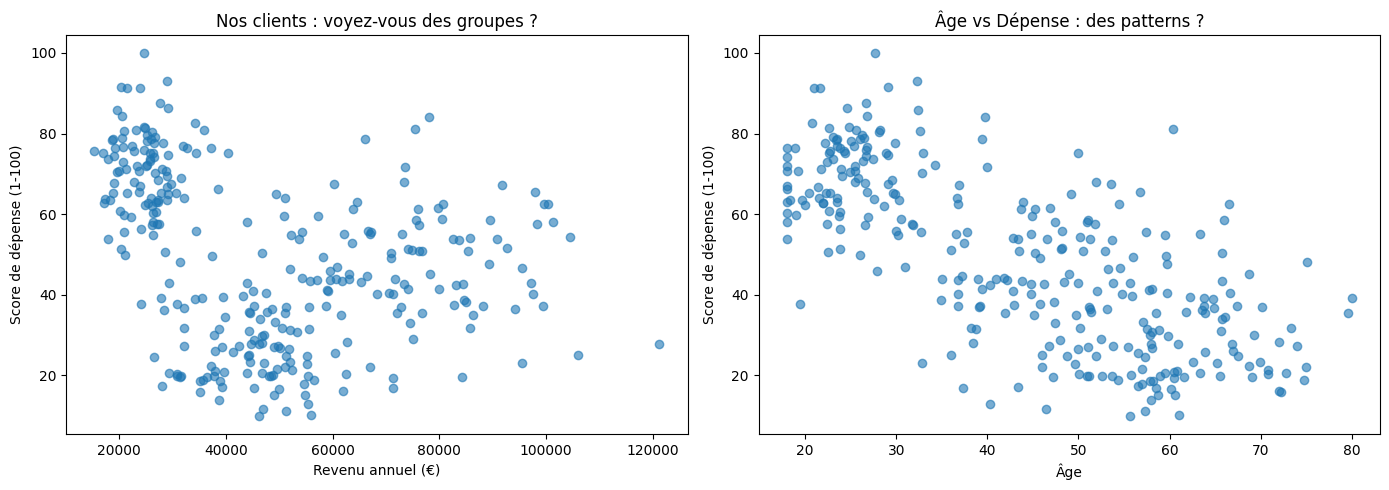

In [2]:
# Visualiser les données (on "voit" les groupes, mais l'algorithme ne sait pas)
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121)
ax1.scatter(clients['revenu_annuel'], clients['score_depense'], alpha=0.6)
ax1.set_xlabel('Revenu annuel (€)')
ax1.set_ylabel('Score de dépense (1-100)')
ax1.set_title('Nos clients : voyez-vous des groupes ?')

ax2 = fig.add_subplot(122)
ax2.scatter(clients['age'], clients['score_depense'], alpha=0.6)
ax2.set_xlabel('Âge')
ax2.set_ylabel('Score de dépense (1-100)')
ax2.set_title('Âge vs Dépense : des patterns ?')

plt.tight_layout()
plt.show()

**Question :** En regardant ces graphiques, combien de groupes naturels voyez-vous ?

*(Réponse attendue : On peut distinguer 2 à 3 groupes, mais ce n'est pas évident. C'est exactement le travail du clustering : trouver ces groupes automatiquement.)*

---

## 4.2 L'Algorithme K-Means : Étape par Étape

K-Means est l'algorithme de clustering le plus utilisé. Son fonctionnement est simple et intuitif :

```
┌───────────────────────────────────────────────────────────────────────┐
│              ALGORITHME K-MEANS (pour K=3 clusters)                   │
├───────────────────────────────────────────────────────────────────────┤
│                                                                       │
│  ÉTAPE 1: Choisir K centres au hasard                                 │
│  ─────────────────────────────────                                    │
│        ·  ·     ·                                                     │
│     ·    ★        ·     ★ = centre de cluster (centroïde)            │
│   ·   ·    ★   ·                                                      │
│      ·  ·    ·   ★                                                    │
│                                                                       │
│  ÉTAPE 2: Assigner chaque point au centre le plus proche              │
│  ─────────────────────────────────────────────────                    │
│        🔴  🔴     🔵                                                   │
│     🔴    ★        🔵     Chaque point prend la couleur               │
│   🔴   🔴    ★   🔵       de son centre le plus proche                │
│      🟢  🟢    🟢   ★                                                  │
│                                                                       │
│  ÉTAPE 3: Recalculer les centres (moyenne de chaque groupe)           │
│  ─────────────────────────────────────────────────────────            │
│        🔴  🔴     🔵                                                   │
│     🔴  ★          🔵     ★ se déplace vers le centre                 │
│   🔴   🔴      ★  🔵       de son groupe                              │
│      🟢  🟢  ★  🟢                                                     │
│                                                                       │
│  ÉTAPE 4: Répéter étapes 2-3 jusqu'à stabilité                        │
│  ──────────────────────────────────────────────                       │
│  (les centres ne bougent plus = convergence)                          │
│                                                                       │
└───────────────────────────────────────────────────────────────────────┘
```

### Construction

In [12]:
# Normaliser les données (important pour K-Means !)
# Lorsque vous travaillez avec des algorithmes basés sur la distance, comme le regroupement k-Means, vous devez normaliser les données. 
# Si nous ne normalisons pas les données, les variables ayant une échelle différente seront pondérées différemment dans la formule de distance optimisée pendant la formation

scaler = StandardScaler()
X_scaled = scaler.fit_transform(clients)

In [ ]:
# Pour la première itération, nous choisirons un nombre de grappes (appelé k) de 3 car il y a 3 groupes distincts dans le dataframe.
# Nous allons créer une instance de KMeans, définir le nombre de grappes à l'aide de l'attribut n_clusters, 
# fixer n_init, qui définit le nombre d'itérations que l'algorithme exécutera avec différentes graines de centroïdes,
# et fixer random_state à 0 afin d'obtenir le même résultat à chaque fois que nous exécutons le code. 

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)


In [ ]:
# Ajouter les clusters aux données
clusters = kmeans.fit_predict(X_scaled)
clients['cluster'] = clusters
display(clients.head())

,age,revenu_annuel,score_depense,cluster
0,27.483571,17923.146290,73.577874,1
1,24.308678,22896.773386,75.607845,1
2,28.238443,23286.427417,80.830512,1
3,32.615149,20988.613654,80.538021,1
4,23.829233,24193.571442,56.223306,1
5,23.829315,27020.254284,60.621750,1
6,32.896064,34430.929506,75.150353,1
7,28.837174,25872.889064,75.137860,1
8,22.652628,26287.751954,75.150477,1
9,27.712800,24627.770421,100.000000,1


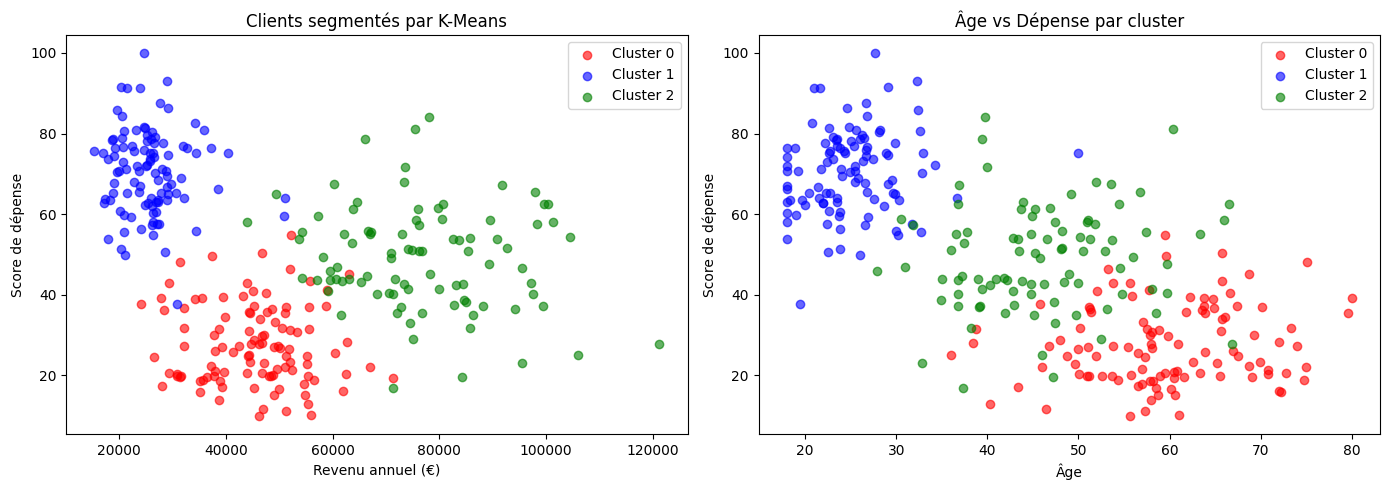

In [ ]:
# Visualiser le résultat
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['red', 'blue', 'green']
for i in range(3):
    mask = clients['cluster'] == i
    axes[0].scatter(clients.loc[mask, 'revenu_annuel'], 
                    clients.loc[mask, 'score_depense'],
                    c=colors[i], label=f'Cluster {i}', alpha=0.6)
    axes[1].scatter(clients.loc[mask, 'age'], 
                    clients.loc[mask, 'score_depense'],
                    c=colors[i], label=f'Cluster {i}', alpha=0.6)

axes[0].set_xlabel('Revenu annuel (€)')
axes[0].set_ylabel('Score de dépense')
axes[0].set_title('Clients segmentés par K-Means')
axes[0].legend()

axes[1].set_xlabel('Âge')
axes[1].set_ylabel('Score de dépense')
axes[1].set_title('Âge vs Dépense par cluster')
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpréter les clusters

In [ ]:
# Statistiques par cluster
print("\n" + "═" * 70)
print("PROFIL DE CHAQUE CLUSTER")
print("═" * 70)

cluster_stats = clients.groupby('cluster').agg({
    'age': 'mean',
    'revenu_annuel': 'mean',
    'score_depense': 'mean'
}).round(1)

cluster_stats['nb_clients'] = clients.groupby('cluster').size()

print(cluster_stats)

# Interprétation
print("\n" + "═" * 70)
print("INTERPRÉTATION BUSINESS")
print("═" * 70)

interpretations = {
    0: "🎯 Cluster 0 : Seniors économes - Âge élevé, faible dépense\n   → Offres promotionnelles, réductions seniors",
    1: "🎯 Cluster 1 : Jeunes dépensiers - Faible revenu, forte dépense\n   → Cibler avec offres tendance, paiement fractionné",
    2: "🎯 Cluster 2 :  Familles aisées - Revenu élevé, dépense moyenne\n   → Proposer produits premium, programmes fidélité famille",
    
}

for cluster_id, interpretation in interpretations.items():
    print(f"\n{interpretation}")


══════════════════════════════════════════════════════════════════════
PROFIL DE CHAQUE CLUSTER
══════════════════════════════════════════════════════════════════════
          age  revenu_annuel  score_depense  nb_clients
cluster                                                
0        59.6        45417.2           27.6         107
1        25.0        25763.2           70.4         103
2        46.0        76752.6           48.9          90

══════════════════════════════════════════════════════════════════════
INTERPRÉTATION BUSINESS
══════════════════════════════════════════════════════════════════════

🎯 Cluster 0 : Jeunes dépensiers - Faible revenu, forte dépense
   → Cibler avec offres tendance, paiement fractionné

🎯 Cluster 1 : Familles aisées - Revenu élevé, dépense moyenne
   → Proposer produits premium, programmes fidélité famille

🎯 Cluster 2 : Seniors économes - Âge élevé, faible dépense
   → Offres promotionnelles, réductions seniors


In [34]:
from sklearn.metrics import silhouette_score

# L'Inertie est déjà calculée automatiquement après le fit
print(f"📉 Inertie (Cohésion interne) : {kmeans.inertia_:.2f}")

# Le Score Silhouette (Demande un peu plus de calcul)
# On lui donne les données (X) et les étiquettes trouvées (labels)
score_sil = silhouette_score(X_scaled, kmeans.labels_)
print(f"📊 Score Silhouette (Séparation) : {score_sil:.2f} (Idéalement proche de 1)")

📉 Inertie (Cohésion interne) : 207.87
📊 Score Silhouette (Séparation) : 0.53 (Idéalement proche de 1)


<details>
<summary>🤔 Question Socratique : Pourquoi faut-il normaliser les données avant K-Means ?</summary>

### 🔑 Réponse

K-Means utilise la **distance** entre les points. Si une variable a une grande échelle (ex: revenu en milliers) et une autre une petite échelle (ex: âge), la première va **dominer** le calcul de distance.

**Exemple :**
- Client A : 25 ans, 30 000€ de revenu
- Client B : 60 ans, 30 100€ de revenu

Sans normalisation, l'algorithme considérerait A et B comme très proches (différence de seulement 100€), alors qu'ils ont 35 ans d'écart !

**StandardScaler** ramène toutes les variables à la même échelle (moyenne 0, écart-type 1).

</details>

---

## 4.3 Choisir K : La Méthode du Coude

**Le problème :** K-Means nécessite de choisir K (le nombre de clusters) **avant** de lancer l'algorithme. Mais comment savoir combien de groupes existent dans nos données ?

### L'inertie : mesurer la "qualité" des clusters

L'**inertie** = somme des distances entre chaque point et le centre de son cluster.

- **Inertie basse** = clusters compacts = bien !
- **Inertie haute** = clusters dispersés = mauvais

**Question :** Si on augmente K (plus de clusters), que se passe-t-il avec l'inertie ?

*(Réponse attendue : L'inertie diminue toujours quand K augmente. Avec K = n (un cluster par point), l'inertie serait 0 !)*

Nous devons tester des fourchettes de valeurs et prendre une décision sur la meilleure valeur de k. Nous prenons généralement une décision à l'aide de la méthode du coude pour déterminer le nombre optimal de grappes afin de ne pas suradapter les données avec un trop grand nombre de grappes et de ne pas les sous-adapter avec un trop petit nombre de grappes. 

In [ ]:
# Calculer l'inertie pour différentes valeurs de K
X_for_elbow = clients[['age', 'revenu_annuel', 'score_depense']]
X_scaled_elbow = scaler.fit_transform(X_for_elbow)

In [ ]:
#Nous créons la boucle ci-dessous pour tester et stocker les différents résultats du modèle afin de prendre une décision sur le meilleur nombre de grappes.

inerties = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled_elbow)
    inerties.append(kmeans_temp.inertia_)

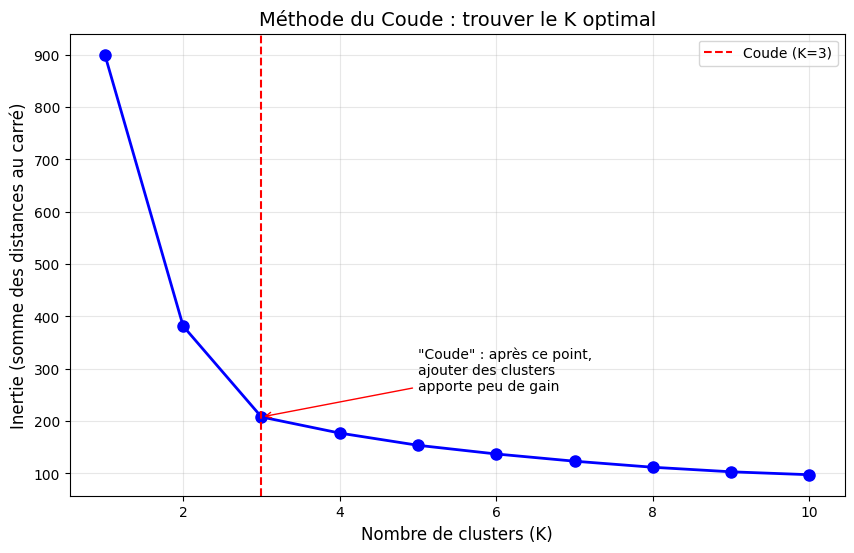

In [ ]:
# Nous pouvons donc commencer par examiner visuellement quelques valeurs différentes de k. 

# Tracer la courbe
plt.figure(figsize=(10, 6))
plt.plot(K_range, inerties, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='Coude (K=3)')
plt.xlabel('Nombre de clusters (K)', fontsize=12)
plt.ylabel('Inertie (somme des distances au carré)', fontsize=12)
plt.title('Méthode du Coude : trouver le K optimal', fontsize=14)

# Annoter le coude
plt.annotate('"Coude" : après ce point,\najouter des clusters\napporte peu de gain',
             xy=(3, inerties[2]), xytext=(5, inerties[2] + 50),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Comment lire le graphique ?

On cherche le **"coude"** : le point où la courbe commence à s'aplatir.

- **Avant le coude** : chaque cluster supplémentaire apporte beaucoup (forte réduction d'inertie)
- **Après le coude** : les gains deviennent marginaux (on "sur-segmente")

Ici, le coude est à **K=3**, ce qui correspond bien aux 3 groupes que nous avions simulés !

### Le score de silhouette : une mesure complémentaire

/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extma

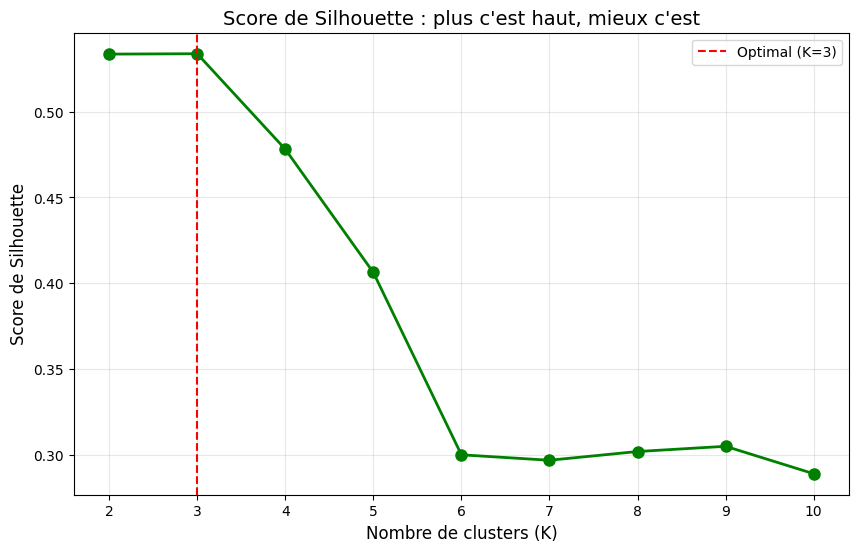


🏆 Meilleur silhouette score : K=3 avec 0.534


In [6]:
from sklearn.metrics import silhouette_score

# Calculer le silhouette score pour différents K
silhouettes = []
for k in range(2, 11):  # silhouette n'existe pas pour K=1
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_scaled_elbow)
    sil = silhouette_score(X_scaled_elbow, labels)
    silhouettes.append(sil)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouettes, 'go-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='Optimal (K=3)')
plt.xlabel('Nombre de clusters (K)', fontsize=12)
plt.ylabel('Score de Silhouette', fontsize=12)
plt.title('Score de Silhouette : plus c\'est haut, mieux c\'est', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n🏆 Meilleur silhouette score : K={range(2,11)[silhouettes.index(max(silhouettes))]} avec {max(silhouettes):.3f}")

````markdown
┌─────────────────────────────────────────────────────────────────────────┐
│ 📖 DÉFINITION : Score de Silhouette                                     │
│                                                                         │
│ Le **score de silhouette** mesure à quel point chaque point est bien    │
│ assigné à son cluster par rapport aux autres clusters.                  │
│                                                                         │
│ • Valeur entre -1 et +1                                                 │
│ • +1 = point très bien dans son cluster, loin des autres               │
│ •  0 = point à la frontière entre deux clusters                        │
│ • -1 = point probablement mal assigné                                  │
│                                                                         │
│ On cherche le K qui **maximise** le score de silhouette moyen.         │
└─────────────────────────────────────────────────────────────────────────┘
```

---

## 4.4 Le Grand Changement : Passer du Supervisé au Non-Supervisé

Jusqu'à présent, nous avons fait de l'apprentissage **Supervisé** (Régression, Classification). Aujourd'hui, avec K-Means (Clustering), nous changeons de paradigme. C'est de l'apprentissage **Non-Supervisé**.

Cela change deux règles fondamentales que vous connaissiez.

### Pourquoi il n'y a pas de "y" (Target) ?

Dans nos cours précédents (ex: prédire le prix d'une maison ou détecter un spam), nous avions toujours une colonne **`y`** : la réponse correcte. Nous donnions au modèle les données (`X`) et la réponse (`y`) pour qu'il apprenne la relation entre les deux.

**En Clustering (K-Means), cette colonne réponse n'existe pas.**

* **L'Analogie de l'Explorateur :**
* **Supervisé :** C'est comme un élève qui révise avec les corrigés. Il sait si sa réponse est juste ou fausse.
* **Non-Supervisé (K-Means) :** C'est comme un explorateur qui débarque sur une planète inconnue. Il voit des animaux (les données), mais personne n'est là pour lui dire "Ça c'est un chat" ou "Ça c'est un chien". Il n'y a pas d'étiquette.


* **La Mission du Modèle :**
Puisqu'il n'a pas de `y` en entrée, le but du K-Means est de **créer** ce `y`. Il doit observer les données et dire : *"Tiens, ces points-là se ressemblent beaucoup, je vais décider qu'ils forment le Groupe 1"*.

> **En résumé :** On ne donne pas la réponse au modèle, on lui demande de **l'inventer** en se basant sur les ressemblances.


### Pourquoi on ne fait pas de "Train / Test Split" ?

D'habitude, on coupe nos données (80% pour entraîner, 20% pour tester) pour vérifier si le modèle se trompe sur des données qu'il ne connaît pas.

**Mais ici, on ne peut pas "se tromper" !**

Puisqu'il n'y a pas de "vraie réponse" (pas de `y` au départ), on ne peut pas calculer de précision (Accuracy). Dire *"Ce client est dans le groupe 1"* n'est ni vrai ni faux, c'est juste une observation.

* **L'Analogie du Plan de Table de Mariage :**
Imaginez que vous devez placer 100 invités à des tables en fonction de leurs affinités (âge, hobbies, famille).
* Est-ce que vous allez faire le plan de table pour seulement 80 invités et laisser les 20 autres debout dans le couloir pour "tester" votre plan plus tard ?
* **Non !** Vous voulez que **tout le monde** ait une place. Vous utilisez 100% de vos invités pour créer les meilleurs groupes possibles.


* **La Logique Business :**
Quand on fait une segmentation client, on veut connaître le profil de **tous** nos clients actuels pour lancer une campagne marketing. Si on cache 20% des clients au modèle (dans un `X_test`), ces clients n'auront pas de segment attribué. Ce serait une perte d'information inutile.

> **En résumé :** Comme on ne cherche pas à prédire l'avenir mais à **décrire le présent**, on donne **100% des données** au modèle pour qu'il ait la vision la plus complète possible.


### **Tableau Récapitulatif**

| Question | Apprentissage Supervisé (Régression/Classif) | Apprentissage Non-Supervisé (K-Means) |
| --- | --- | --- |
| **A-t-on la réponse (`y`) ?** | **OUI** (On apprend par l'exemple) | **NON** (On apprend par observation) |
| **Fait-on un Split ?** | **OUI** (Pour vérifier la précision) | **NON** (On veut segmenter tout le monde) |
| **Objectif** | Prédire une valeur future | Trouver des groupes cachés |

---

## 4.5 Cas d'Usage Réels

Le clustering K-Means est utilisé dans de nombreux domaines :

### 1. Segmentation clients (marketing)

C'est l'exemple que nous avons vu. Les entreprises segmentent leurs clients pour :
- Personnaliser les campagnes marketing
- Adapter les prix et promotions
- Identifier les clients à risque de churn

### 2. Détection d'anomalies

Les points qui sont **loin** de tout centroïde peuvent être des anomalies :
- Transactions frauduleuses
- Défauts de fabrication
- Comportements suspects

### 3. Compression d'images

K-Means peut réduire le nombre de couleurs d'une image :
- Chaque pixel = un point dans l'espace RGB
- K-Means trouve K couleurs représentatives
- Chaque pixel est remplacé par la couleur de son cluster

### 4. Regroupement de documents

Après avoir transformé des textes en vecteurs (embeddings), K-Means peut :
- Grouper des articles par thème
- Organiser des emails par catégorie
- Identifier des tendances dans les avis clients

---

## 🧪 Exercice Pratique : Segmenter un dataset de cartes de crédit

Analysez les comportements de clients bancaires.

In [27]:
# Créer un dataset de cartes de crédit simplifié
np.random.seed(123)
n_cc = 500

credit_cards = pd.DataFrame({
    'solde_moyen': np.concatenate([
        np.random.uniform(100, 1000, 200),    # Petits utilisateurs
        np.random.uniform(2000, 8000, 200),   # Gros utilisateurs
        np.random.uniform(500, 2000, 100)     # Utilisateurs moyens
    ]),
    'nb_achats_mois': np.concatenate([
        np.random.uniform(1, 10, 200),
        np.random.uniform(20, 50, 200),
        np.random.uniform(10, 25, 100)
    ]),
    'limite_credit': np.concatenate([
        np.random.uniform(2000, 5000, 200),
        np.random.uniform(10000, 30000, 200),
        np.random.uniform(5000, 15000, 100)
    ])
})

# Ajouter le ratio d'utilisation
#credit_cards['ratio_utilisation'] = (credit_cards['solde_moyen'] / 
 #                                     credit_cards['limite_credit'] * 100).clip(0, 100)

print("Dataset Cartes de Crédit :")
display(credit_cards.head())
print(f"\nStatistiques :")
print(credit_cards.describe().round(1))

Dataset Cartes de Crédit :


,solde_moyen,nb_achats_mois,limite_credit
0,726.822267,2.915483,2245.683317
1,357.525401,4.530737,3485.118895
2,304.166308,8.663932,2866.670206
3,596.183292,2.148510,3919.975606
4,747.522073,9.044788,3499.807842



Statistiques :
       solde_moyen  nb_achats_mois  limite_credit
count        500.0           500.0          500.0
mean        2443.5            19.8        11595.6
std         2355.6            14.7         8797.1
min          102.4             1.0         2000.4
25%          614.4             6.8         3719.1
50%         1148.9            16.4        10100.2
75%         4093.9            31.5        17719.1
max         7976.5            49.8        29984.0


### Votre mission :

1. Normalisez les données avec StandardScaler
2. Utilisez la méthode du coude pour trouver le K optimal
3. Appliquez K-Means avec le K choisi
4. Calculez les statistiques moyennes par cluster
5. Donnez un "nom marketing" à chaque segment

In [9]:
# 🎯 À VOUS DE JOUER !

# Étape 1 : Normaliser
# scaler = ...
# X_cc_scaled = ...

# Étape 2 : Méthode du coude
# ...

# Étape 3 : Appliquer K-Means
# kmeans_cc = ...

# Étape 4 : Statistiques par cluster
# ...

# Étape 5 : Interprétation

## 🔑 Réponse à l'exercice

In [28]:
# Étape 1 : Normaliser
# # Indispensable en K-Means car les échelles sont très différentes (Achats vs Limite crédit)
scaler_cc = StandardScaler()
X_cc_scaled = scaler_cc.fit_transform(credit_cards)

In [29]:
# Étape 2 : Méthode du coude
inerties_cc = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cc_scaled)
    inerties_cc.append(km.inertia_)

/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extma

/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_68204/2680012582.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


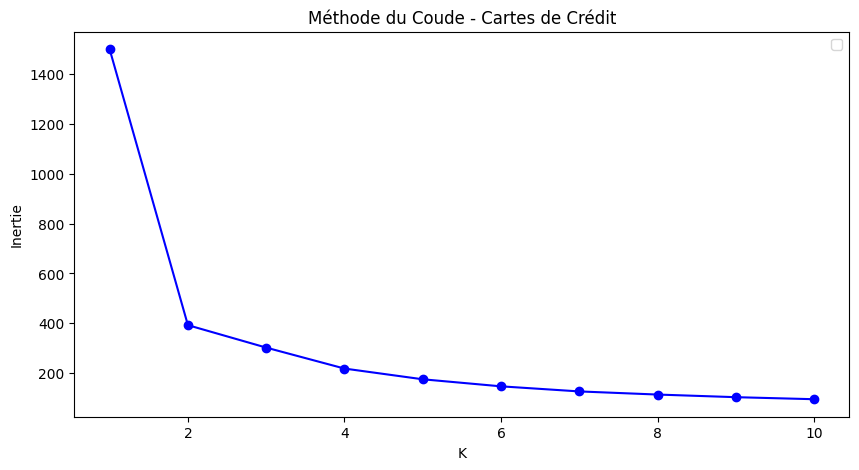

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), inerties_cc, 'bo-')
plt.xlabel('K')
plt.ylabel('Inertie')
plt.title('Méthode du Coude - Cartes de Crédit')
plt.legend()
plt.show()

In [31]:
# Étape 3 : Appliquer K-Means

# (On utilise TOUT le dataset) ---
# Pas de 'y' ici ! Le modèle travaille en aveugle pour trouver des structures.
kmeans_cc = KMeans(n_clusters=3, random_state=42, n_init=10)

# fit_predict : Le modèle apprend la géographie ET place les clients actuels
credit_cards['cluster'] = kmeans_cc.fit_predict(X_cc_scaled)

/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [32]:
# Étape 4 : Statistiques
print("\n" + "═" * 60)
print("PROFILS DES SEGMENTS")
print("═" * 60)
print(credit_cards.groupby('cluster').mean().round(1))

# Étape 5 : Interprétation
print("\n" + "═" * 60)
print("NOMS MARKETING SUGGÉRÉS")
print("═" * 60)
print("""
🏷️ Cluster 0 : "Utilisateurs occasionnels"
   - Faible solde, peu d'achats, petite limite
   → Cible pour upgrade de carte

🏷️ Cluster 1 : "Power Users"
   - Solde élevé, nombreux achats, grande limite
   → Programme de fidélité premium

🏷️ Cluster 2 : "Utilisateurs modérés"
   - Valeurs moyennes sur tous les critères
   → Potentiel de croissance, offres ciblées
""")


════════════════════════════════════════════════════════════
PROFILS DES SEGMENTS
════════════════════════════════════════════════════════════
         solde_moyen  nb_achats_mois  limite_credit
cluster                                            
0              575.3             5.9         3435.8
1             5096.8            36.2        20969.5
2             1453.4            18.2        11158.7

════════════════════════════════════════════════════════════
NOMS MARKETING SUGGÉRÉS
════════════════════════════════════════════════════════════

🏷️ Cluster 0 : "Utilisateurs occasionnels"
   - Faible solde, peu d'achats, petite limite
   → Cible pour upgrade de carte

🏷️ Cluster 1 : "Power Users"
   - Solde élevé, nombreux achats, grande limite
   → Programme de fidélité premium

🏷️ Cluster 2 : "Utilisateurs modérés"
   - Valeurs moyennes sur tous les critères
   → Potentiel de croissance, offres ciblées



In [ ]:
# Étape 6 : LE CAS DES NOUVEAUX CLIENTS (La "Prédiction") 
# C'est ici que ça ressemble à du test : des données que le modèle n'a jamais vues.

print("🚀 ARRIVÉE DE 3 NOUVEAUX CLIENTS :")
nouveaux_clients = pd.DataFrame({
    'solde_moyen': [150.0, 7500.0, 500],      # Un petit, un gros
    'nb_achats_mois': [2.0, 45.0, 23],
    'limite_credit': [2500.0, 28000.0, 10000.0]
})
display(nouveaux_clients)

# ATTENTION : On utilise le MÊME scaler (ne pas refaire fit !)
X_nouveaux_scaled = scaler_cc.transform(nouveaux_clients)

# On demande au modèle : "Dans quel groupe ils vont ?"
nouveaux_clusters = kmeans_cc.predict(X_nouveaux_scaled)

print(f"\n🔮 CLASSEMENT :")
print(f"Le client 1 (Petit budget) va dans le cluster : {nouveaux_clusters[0]}")
print(f"Le client 2 (VIP) va dans le cluster          : {nouveaux_clusters[1]}")
print(f"Le client 3 (Modéré) va dans le cluster          : {nouveaux_clusters[2]}")

🚀 ARRIVÉE DE 2 NOUVEAUX CLIENTS :


,solde_moyen,nb_achats_mois,limite_credit
0,150.0,2.0,2500.0
1,7500.0,45.0,28000.0
2,500.0,23.0,10000.0



🔮 CLASSEMENT :
Le client 1 (Petit budget) va dans le cluster : 0
Le client 2 (VIP) va dans le cluster          : 1
Le client 3 (Modéré) va dans le cluster          : 2


---

## 📚 Récapitulatif

### Ce que vous avez appris :

1. **Non-supervisé** : Pas de labels, on cherche des groupes naturels
2. **K-Means** : Algorithme itératif (assigner → recalculer → répéter)
3. **Méthode du coude** : Trouver le bon nombre de clusters
4. **Silhouette** : Mesure complémentaire de qualité
5. **Interprétation** : Les clusters doivent avoir un sens business

### Code essentiel :

```python
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Normaliser (obligatoire !)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Méthode du coude
inerties = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inerties.append(km.inertia_)

# 3. Appliquer K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 4. Évaluer
sil = silhouette_score(X_scaled, clusters)
```

### Prochaine partie : Quand Utiliser Quoi ?

Maintenant que vous connaissez 4 algorithmes, comment choisir le bon pour votre problème ?

---

## 🤔 Réflexion Métacognitive

Avant de passer à la suite :

1. Pouvez-vous expliquer la différence entre classification supervisée et clustering ?
2. Pourquoi la normalisation est-elle critique pour K-Means ?
3. Dans votre domaine, voyez-vous une application du clustering ?

---

**Sources :**
- [MDPI 2024 - Clustering Algorithms for Customer Segmentation in UK Retail](https://www.mdpi.com/2813-2203/2/4/42)
- [ResearchGate 2024 - Customer Segmentation Using K-Means Clustering](https://www.researchgate.net/publication/392202209_Customer_Segmentation_Using_K-Means_Clustering_for_Personalized_Marketing_Campaigns)
- [scikit-learn KMeans Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)